# Домашнее задание №1

In [64]:
import os
import re
import random
import hashlib
import inspect
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, Any
from collections import Counter

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    get_linear_schedule_with_warmup,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [2]:
repo_root = Path('.').resolve()

train_idx_path = repo_root / 'train_idx.txt'
val_idx_path   = repo_root / 'val_idx.txt'
test_idx_path  = repo_root / 'test_idx.txt'

assert train_idx_path.exists(), f'No {train_idx_path}'
assert val_idx_path.exists(), f'No {val_idx_path}'
assert test_idx_path.exists(), f'No {test_idx_path}'

train_idx = np.loadtxt(train_idx_path, dtype=np.int64)
val_idx   = np.loadtxt(val_idx_path, dtype=np.int64)
test_idx  = np.loadtxt(test_idx_path, dtype=np.int64)

print('sizes:', len(train_idx), len(val_idx), len(test_idx))
print('overlaps:',
      len(set(train_idx)&set(val_idx)),
      len(set(train_idx)&set(test_idx)),
      len(set(val_idx)&set(test_idx)))

sizes: 49412 6176 6177
overlaps: 0 0 0


In [3]:
DATASET = "Tobi-Bueck/customer-support-tickets"

ds = load_dataset(DATASET)["train"]   # в этом датасете один сплит train, а мы сами режем индексами
df = ds.to_pandas()

print(df.shape)
print(df.columns)

# type: пропуски = Unknown
df["type"] = df["type"].fillna("Unknown")

# текст для модели: subject + body
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["text"] = (df["subject"] + "\n\n" + df["body"]).astype(str)

# применяем фиксированный split
train_df = df.iloc[train_idx].copy()
val_df   = df.iloc[val_idx].copy()
test_df  = df.iloc[test_idx].copy()

print("splits:", train_df.shape, val_df.shape, test_df.shape)

# sanity-check
train_df.head(2)[["language","queue","priority","type","subject","body"]]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

(61765, 16)
Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')
splits: (49412, 17) (6176, 17) (6177, 17)


,language,queue,priority,type,subject,body
0,de,Technical Support,high,Incident,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine..."
1,en,Technical Support,high,Incident,Account Disruption,"Dear Customer Support Team,\n\nI am writing to..."


# EDA

***Размеры текстов и языки***

In [5]:
def len_stats(s):
    ch = s.str.len()
    wd = s.str.split().map(len)
    return {
        "chars_mean": round(ch.mean(), 1),
        "chars_p50": int(ch.median()),
        "chars_p90": int(ch.quantile(.9)),
        "chars_p99": int(ch.quantile(.99)),
        "words_mean": round(wd.mean(), 1),
        "words_p50": int(wd.median()),
        "words_p90": int(wd.quantile(.9)),
        "words_p99": int(wd.quantile(.99)),
    }

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n===", name, "===")
    print("language:", d["language"].value_counts(normalize=True).round(3).to_dict())
    print("text lens:", len_stats(d["text"]))

print("\n=== queue distribution (train) ===")
vc = train_df["queue"].astype(str).value_counts()
print("n_classes:", vc.shape[0], "min_count:", vc.min(), "<=5:", int((vc<=5).sum()))
vc.head(10), vc.tail(10)


=== train ===
language: {'de': 0.542, 'en': 0.458}
text lens: {'chars_mean': np.float64(464.8), 'chars_p50': 460, 'chars_p90': 755, 'chars_p99': 998, 'words_mean': np.float64(62.4), 'words_p50': 62, 'words_p90': 99, 'words_p99': 143}

=== val ===
language: {'de': 0.546, 'en': 0.454}
text lens: {'chars_mean': np.float64(466.7), 'chars_p50': 463, 'chars_p90': 753, 'chars_p99': 1009, 'words_mean': np.float64(62.7), 'words_p50': 62, 'words_p90': 98, 'words_p99': 142}

=== test ===
language: {'de': 0.539, 'en': 0.461}
text lens: {'chars_mean': np.float64(460.3), 'chars_p50': 454, 'chars_p90': 751, 'chars_p99': 1015, 'words_mean': np.float64(62.1), 'words_p50': 62, 'words_p90': 98, 'words_p99': 147}

=== queue distribution (train) ===
n_classes: 52 min_count: 187 <=5: 0


(queue
 Technical Support                  11354
 Product Support                     7139
 Customer Service                    5905
 IT Support                          4673
 Billing and Payments                3853
 Returns and Exchanges               1956
 Service Outages and Maintenance     1534
 Sales and Pre-Sales                 1228
 Human Resources                      730
 General Inquiry                      532
 Name: count, dtype: int64,
 queue
 Food & Drink/Restaurants                232
 Books & Literature/Fiction              232
 Shopping/Retail Stores                  226
 People & Society/Culture & Society      220
 IT & Technology/Hardware Support        219
 Home & Garden/Landscaping               217
 Arts & Entertainment/Movies             207
 IT & Technology/Software Development    206
 Sports                                  190
 Real Estate                             187
 Name: count, dtype: int64)

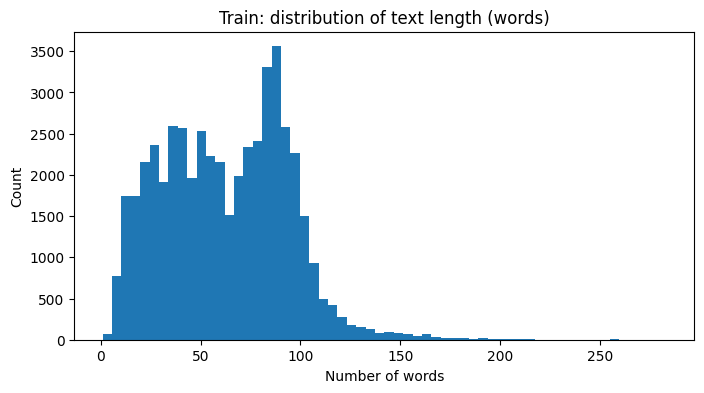

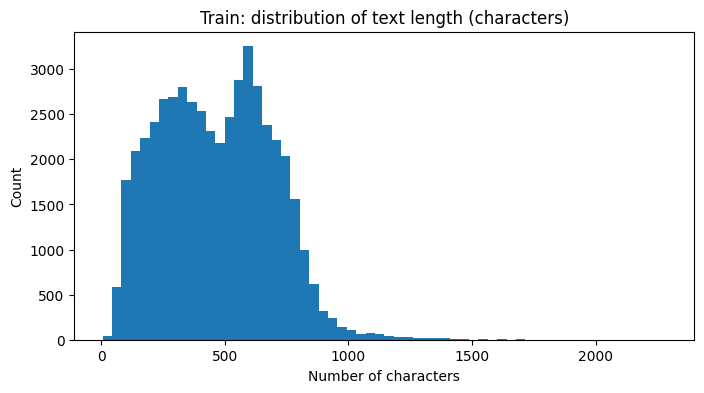

In [65]:
for d in [train_df, val_df, test_df]:
    d["text_len_words"] = d["text"].str.split().str.len()
    d["text_len_chars"] = d["text"].str.len()

plt.figure(figsize=(8, 4))
plt.hist(train_df["text_len_words"], bins=60)
plt.title("Train: distribution of text length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(train_df["text_len_chars"], bins=60)
plt.title("Train: distribution of text length (characters)")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.show()

***Пропуски и пустые поля***

In [6]:
cols = ["subject","body","queue","priority","type","language"]
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n===", name, "===")
    print("missing share:", (d[cols].isna().mean()).round(4).to_dict())
    print("empty subject:", (d["subject"].fillna("").str.strip()=="").mean())
    print("empty body   :", (d["body"].fillna("").str.strip()=="").mean())
    print("empty text   :", (d["text"].fillna("").str.strip()=="").mean())


=== train ===
missing share: {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
empty subject: 0.08637577916295637
empty body   : 4.0475997733344126e-05
empty text   : 0.0

=== val ===
missing share: {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
empty subject: 0.0817681347150259
empty body   : 0.0
empty text   : 0.0

=== test ===
missing share: {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
empty subject: 0.0851546057956937
empty body   : 0.0
empty text   : 0.0


***Пересечения между сплитами***

In [9]:
def hash_text(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def hashes(df_):
    return df_["text"].fillna("").map(hash_text)

h_tr = set(hashes(train_df))
h_va = set(hashes(val_df))
h_te = set(hashes(test_df))

print("overlap train/val:", len(h_tr & h_va))
print("overlap train/test:", len(h_tr & h_te))
print("overlap val/test:", len(h_va & h_te))

overlap train/val: 0
overlap train/test: 0
overlap val/test: 0


***Распределения priority и type***

In [10]:
print("priority dist (train):")
display(train_df["priority"].astype(str).value_counts(normalize=True).round(3))

print("\ntype dist (train):")
display(train_df["type"].astype(str).value_counts(normalize=True).round(3))

print("\nUnknown share (train/val/test):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, (d["type"].astype(str)=="Unknown").mean())

priority dist (train):


,proportion
priority,
medium,0.377
high,0.355
low,0.208
critical,0.031
very_low,0.029



type dist (train):


,proportion
type,
Incident,0.316
Request,0.226
Unknown,0.213
Problem,0.164
Change,0.081



Unknown share (train/val/test):
train 0.21266089209099004
val 0.22344559585492227
test 0.20883924235065565


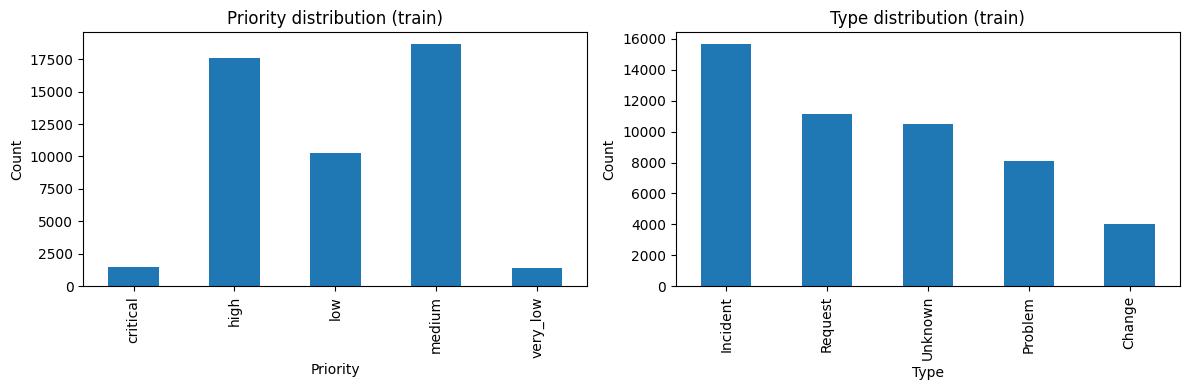

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["priority"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Priority distribution (train)")
axes[0].set_xlabel("Priority")
axes[0].set_ylabel("Count")

train_df["type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Type distribution (train)")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

***Анализ поля answer***

In [11]:
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ans = d["answer"].fillna("").astype(str)
    print(name, "answer empty:", (ans.str.strip()=="").mean(), "answer chars p90:", int(ans.str.len().quantile(.9)))

train answer empty: 0.21288351007852344 answer chars p90: 615
val answer empty: 0.22344559585492227 answer chars p90: 608
test answer empty: 0.20883924235065565 answer chars p90: 608


***Шум в текстах***

In [13]:
URL = re.compile(r"https?://\S+|www\.\S+")
EMAIL = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
DIGIT = re.compile(r"\d")

def noise_stats(series):
    s = series.fillna("").astype(str)
    return {
        "has_url": float(s.str.contains(URL).mean()),
        "has_email": float(s.str.contains(EMAIL).mean()),
        "has_digit": float(s.str.contains(DIGIT).mean()),
    }

print("noise train:", noise_stats(train_df["text"]))

noise train: {'has_url': 0.0, 'has_email': 0.0, 'has_digit': 0.15929328907957582}


***Анализ очень коротких и пустоватых текстов***

In [60]:
train_df["text_len_words"] = train_df["text"].str.split().str.len()
val_df["text_len_words"] = val_df["text"].str.split().str.len()
test_df["text_len_words"] = test_df["text"].str.split().str.len()

for threshold in [3, 5, 10]:
    share = (train_df["text_len_words"] <= threshold).mean()
    print(f"Train: share of texts with <= {threshold} words: {share:.3f}")

Train: share of texts with <= 3 words: 0.000
Train: share of texts with <= 5 words: 0.001
Train: share of texts with <= 10 words: 0.017


***Дубликаты и почти-дубликаты***

In [63]:
print("Exact duplicate texts in full df:", df["text"].duplicated().sum())
print("Exact duplicate texts in train:", train_df["text"].duplicated().sum())
print("Exact duplicate texts in val:", val_df["text"].duplicated().sum())
print("Exact duplicate texts in test:", test_df["text"].duplicated().sum())

Exact duplicate texts in full df: 8306
Exact duplicate texts in train: 6663
Exact duplicate texts in val: 814
Exact duplicate texts in test: 829


***Топ-20 классов queue***

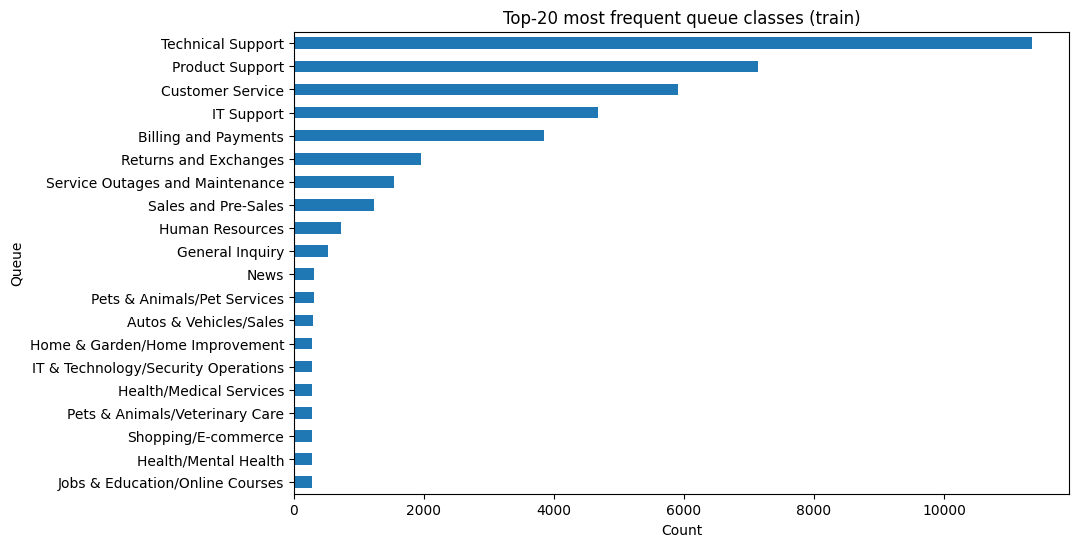

Number of unique queue classes: 52


In [67]:
top_queues = train_df["queue"].value_counts().head(20)

plt.figure(figsize=(10, 6))
top_queues.sort_values().plot(kind="barh")
plt.title("Top-20 most frequent queue classes (train)")
plt.xlabel("Count")
plt.ylabel("Queue")
plt.show()

print("Number of unique queue classes:", train_df["queue"].nunique())

# Baseline: TF-IDF + LinearSVC

In [15]:
vec = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
)

Xtr = vec.fit_transform(train_df["text"])
Xte = vec.transform(test_df["text"])

baseline = {}
preds_baseline = {}

for target in ["queue", "priority", "type"]:
    ytr = train_df[target].astype(str).values
    yte = test_df[target].astype(str).values

    clf = LinearSVC()
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    preds_baseline[target] = pred

    acc = accuracy_score(yte, pred)

    if target == "queue":
        mf1 = f1_score(yte, pred, average="macro")
        baseline["queue_macro_f1"] = mf1
        baseline["queue_acc"] = acc
        print("queue:", f"acc={acc:.4f}", f"macroF1={mf1:.4f}")
    else:
        baseline[f"{target}_acc"] = acc
        print(target + ":", f"acc={acc:.4f}")

baseline["final_score"] = (
    0.70*baseline["queue_macro_f1"] +
    0.15*baseline["priority_acc"] +
    0.15*baseline["type_acc"]
)
print("\nBASELINE FINAL SCORE:", round(baseline["final_score"], 4))

queue: acc=0.6914 macroF1=0.8940
priority: acc=0.7112
type: acc=0.8974

BASELINE FINAL SCORE: 0.8671


# TF-IDF. Версии попыток побить скор безлайна

## №1. Улучшенная TF-IDF на промежуточном этапе (но итоговый победитель будет пониже)

In [4]:
X_train = train_df["text"].astype(str).values
X_val   = val_df["text"].astype(str).values

yq_tr = train_df["queue"].astype(str).values
yp_tr = train_df["priority"].astype(str).values
yt_tr = train_df["type"].astype(str).values

yq_va = val_df["queue"].astype(str).values
yp_va = val_df["priority"].astype(str).values
yt_va = val_df["type"].astype(str).values

vec_grid = [
    dict(max_features=200_000, ngram_range=(1,2), min_df=2, max_df=1.0,  sublinear_tf=False, dtype=np.float32),
    dict(max_features=200_000, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True,  dtype=np.float32),
    dict(max_features=300_000, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True,  dtype=np.float32),
    dict(max_features=200_000, ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True,  dtype=np.float32),
    dict(max_features=300_000, ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True,  dtype=np.float32),
]

C_list  = [0.5, 1.0, 2.0]
cw_list = [None, "balanced"]  # balanced пробуем только для queue

rows = []

for vp in vec_grid:
    vec = TfidfVectorizer(**vp)
    Xtr = vec.fit_transform(X_train)
    Xva = vec.transform(X_val)

    clf_p = LinearSVC(C=1.0, max_iter=5000).fit(Xtr, yp_tr)
    pp = clf_p.predict(Xva)
    p_acc = accuracy_score(yp_va, pp)

    clf_t = LinearSVC(C=1.0, max_iter=5000).fit(Xtr, yt_tr)
    pt = clf_t.predict(Xva)
    t_acc = accuracy_score(yt_va, pt)

    # queue перебираем C и class_weight (это влияет на macro-F1)
    for Cq in C_list:
        for cwq in cw_list:
            clf_q = LinearSVC(C=Cq, class_weight=cwq, max_iter=5000).fit(Xtr, yq_tr)
            pq = clf_q.predict(Xva)

            q_acc = accuracy_score(yq_va, pq)
            q_mf1 = f1_score(yq_va, pq, average="macro")

            final = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc

            rows.append({
                "val_final_score": final,
                "val_queue_macro_f1": q_mf1,
                "val_queue_acc": q_acc,
                "val_priority_acc": p_acc,
                "val_type_acc": t_acc,
                "Cq": Cq,
                "cwq": cwq,
                "vec_params": vp,
            })

res = pd.DataFrame(rows).sort_values("val_final_score", ascending=False)
res.head(10)

,val_final_score,val_queue_macro_f1,val_queue_acc,val_priority_acc,val_type_acc,Cq,cwq,vec_params
16,0.877107,0.906808,0.699320,0.722798,0.892811,2.0,None,"{'max_features': 300000, 'ngram_range': (1, 2)..."
10,0.876635,0.906134,0.698187,0.721988,0.893620,2.0,None,"{'max_features': 200000, 'ngram_range': (1, 2)..."
4,0.875416,0.904775,0.697053,0.720693,0.893135,2.0,None,"{'max_features': 200000, 'ngram_range': (1, 2)..."
28,0.874419,0.900609,0.706120,0.731056,0.895563,2.0,None,"{'max_features': 300000, 'ngram_range': (1, 3)..."
26,0.871886,0.896991,0.696405,0.731056,0.895563,1.0,None,"{'max_features': 300000, 'ngram_range': (1, 3)..."
14,0.871037,0.898137,0.688795,0.722798,0.892811,1.0,None,"{'max_features': 300000, 'ngram_range': (1, 2)..."
2,0.870916,0.898345,0.687986,0.720693,0.893135,1.0,None,"{'max_features': 200000, 'ngram_range': (1, 2)..."
8,0.870736,0.897707,0.686367,0.721988,0.893620,1.0,None,"{'max_features': 200000, 'ngram_range': (1, 2)..."
11,0.869498,0.895938,0.670984,0.721988,0.893620,2.0,balanced,"{'max_features': 200000, 'ngram_range': (1, 2)..."
17,0.869049,0.895296,0.669203,0.722798,0.892811,2.0,balanced,"{'max_features': 300000, 'ngram_range': (1, 2)..."


In [5]:
best = res.iloc[0].to_dict()
best_vec = best["vec_params"]
best_Cq  = float(best["Cq"])
best_cwq = best["cwq"]

print("BEST from grid:", best)

# готовим матрицы один раз
Xtr_text = train_df["text"].astype(str).values
Xva_text = val_df["text"].astype(str).values

yq_tr = train_df["queue"].astype(str).values
yp_tr = train_df["priority"].astype(str).values
yt_tr = train_df["type"].astype(str).values

yq_va = val_df["queue"].astype(str).values
yp_va = val_df["priority"].astype(str).values
yt_va = val_df["type"].astype(str).values

vec = TfidfVectorizer(**best_vec)
Xtr = vec.fit_transform(Xtr_text)
Xva = vec.transform(Xva_text)

# queue — как в best
clf_q = LinearSVC(C=best_Cq, class_weight=best_cwq, max_iter=5000).fit(Xtr, yq_tr)
pq = clf_q.predict(Xva)
q_mf1 = f1_score(yq_va, pq, average="macro")

# priority/type — дотюним C на val
C_grid_pt = [0.5, 1.0, 2.0, 4.0]

best_p = (-1, None)
for Cp in C_grid_pt:
    pp = LinearSVC(C=Cp, max_iter=5000).fit(Xtr, yp_tr).predict(Xva)
    acc = accuracy_score(yp_va, pp)
    if acc > best_p[0]:
        best_p = (acc, Cp)

best_t = (-1, None)
for Ct in C_grid_pt:
    pt = LinearSVC(C=Ct, max_iter=5000).fit(Xtr, yt_tr).predict(Xva)
    acc = accuracy_score(yt_va, pt)
    if acc > best_t[0]:
        best_t = (acc, Ct)

p_acc, Cp_best = best_p
t_acc, Ct_best = best_t

val_final = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc
print("TUNED on VAL:",
      {"q_mf1": q_mf1, "p_acc": p_acc, "t_acc": t_acc, "val_final": val_final,
       "Cq": best_Cq, "cwq": best_cwq, "Cp": Cp_best, "Ct": Ct_best, "vec": best_vec})

BEST from grid: {'val_final_score': 0.8771066359381996, 'val_queue_macro_f1': 0.9068075924209661, 'val_queue_acc': 0.6993199481865285, 'val_priority_acc': 0.7227979274611399, 'val_type_acc': 0.8928108808290155, 'Cq': 2.0, 'cwq': None, 'vec_params': {'max_features': 300000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True, 'dtype': <class 'numpy.float32'>}}
TUNED on VAL: {'q_mf1': 0.9068075924209661, 'p_acc': 0.7292746113989638, 't_acc': 0.8975064766839378, 'val_final': 0.8787824779071115, 'Cq': 2.0, 'cwq': None, 'Cp': 4.0, 'Ct': 4.0, 'vec': {'max_features': 300000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True, 'dtype': <class 'numpy.float32'>}}


In [6]:
best_vec = {
    "max_features": 300000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "dtype": np.float32,
}
best_Cq = 2.0
best_cwq = None
Cp_best = 4.0
Ct_best = 4.0

X_trval = np.concatenate([
    train_df["text"].astype(str).values,
    val_df["text"].astype(str).values
])
X_test = test_df["text"].astype(str).values

yq_trval = np.concatenate([
    train_df["queue"].astype(str).values,
    val_df["queue"].astype(str).values
])
yp_trval = np.concatenate([
    train_df["priority"].astype(str).values,
    val_df["priority"].astype(str).values
])
yt_trval = np.concatenate([
    train_df["type"].astype(str).values,
    val_df["type"].astype(str).values
])

yq_test = test_df["queue"].astype(str).values
yp_test = test_df["priority"].astype(str).values
yt_test = test_df["type"].astype(str).values

vec = TfidfVectorizer(**best_vec)
Xtr = vec.fit_transform(X_trval)
Xte = vec.transform(X_test)

clf_q = LinearSVC(C=best_Cq, class_weight=best_cwq, max_iter=5000).fit(Xtr, yq_trval)
clf_p = LinearSVC(C=Cp_best, max_iter=5000).fit(Xtr, yp_trval)
clf_t = LinearSVC(C=Ct_best, max_iter=5000).fit(Xtr, yt_trval)

pq = clf_q.predict(Xte)
pp = clf_p.predict(Xte)
pt = clf_t.predict(Xte)

q_acc = accuracy_score(yq_test, pq)
q_mf1 = f1_score(yq_test, pq, average="macro")
p_acc = accuracy_score(yp_test, pp)
t_acc = accuracy_score(yt_test, pt)

final_score = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc

print("TEST METRICS:")
print({
    "test_queue_acc": q_acc,
    "test_queue_macro_f1": q_mf1,
    "test_priority_acc": p_acc,
    "test_type_acc": t_acc,
    "test_final_score": final_score
})

TEST METRICS:
{'test_queue_acc': 0.7157196049862393, 'test_queue_macro_f1': 0.9123444163683541, 'test_priority_acc': 0.7374129836490205, 'test_type_acc': 0.9070746316982354, 'test_final_score': 0.8853142337599361}


## №2. Абсолютный победитель в разряде TD-IDF в этом ноутбуке!

In [7]:
# лучший TF-IDF, который уже дал топ результат
best_vec = {
    "max_features": 300000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "dtype": np.float32,
}

X_train = train_df["text"].astype(str).values
X_val   = val_df["text"].astype(str).values

yq_tr = train_df["queue"].astype(str).values
yp_tr = train_df["priority"].astype(str).values
yt_tr = train_df["type"].astype(str).values

yq_va = val_df["queue"].astype(str).values
yp_va = val_df["priority"].astype(str).values
yt_va = val_df["type"].astype(str).values

vec = TfidfVectorizer(**best_vec)
Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

Xtr.shape, Xva.shape

((49412, 205723), (6176, 205723))

In [9]:
def eval_models(pq, pp, pt):
    q_mf1 = f1_score(yq_va, pq, average="macro")
    p_acc = accuracy_score(yp_va, pp)
    t_acc = accuracy_score(yt_va, pt)
    score = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc
    return {"val_queue_macro_f1": q_mf1, "val_priority_acc": p_acc, "val_type_acc": t_acc, "val_final_score": score}

clf_p = LinearSVC(C=4.0, max_iter=5000).fit(Xtr, yp_tr)
pp = clf_p.predict(Xva)

clf_t = LinearSVC(C=4.0, max_iter=5000).fit(Xtr, yt_tr)
pt = clf_t.predict(Xva)

# веса по частотам классов queue
freq = Counter(yq_tr)
w_class = {c: 1.0/freq[c] for c in freq}  # базово 1/freq, дальше смягчим степенью
w_raw = np.array([w_class[c] for c in yq_tr], dtype=np.float32)

# 0 = без весов, 0.5 = мягко (sqrt), 1 = жестко (1/freq)
alphas = [0.0, 0.5, 1.0]
results = []

for a in alphas:
    if a == 0.0:
        sw = None
    else:
        sw = (w_raw ** a)
        sw = sw / sw.mean()  # нормируем, чтобы средний вес был ~1

    clf_q = LinearSVC(C=2.0, max_iter=5000)  # лучший Cq
    if sw is None:
        clf_q.fit(Xtr, yq_tr)
    else:
        clf_q.fit(Xtr, yq_tr, sample_weight=sw)

    pq = clf_q.predict(Xva)
    m = eval_models(pq, pp, pt)
    m.update({"alpha": a})
    results.append(m)

results

[{'val_queue_macro_f1': 0.9068075924209661,
  'val_priority_acc': 0.7292746113989638,
  'val_type_acc': 0.8975064766839378,
  'val_final_score': 0.8787824779071115,
  'alpha': 0.0},
 {'val_queue_macro_f1': 0.9068194220399756,
  'val_priority_acc': 0.7292746113989638,
  'val_type_acc': 0.8975064766839378,
  'val_final_score': 0.8787907586404181,
  'alpha': 0.5},
 {'val_queue_macro_f1': 0.8968119130512663,
  'val_priority_acc': 0.7292746113989638,
  'val_type_acc': 0.8975064766839378,
  'val_final_score': 0.8717855023483216,
  'alpha': 1.0}]

In [10]:
best_alpha = 0.5

X_trval = np.concatenate([train_df["text"].astype(str).values, val_df["text"].astype(str).values])
X_test  = test_df["text"].astype(str).values

yq_trval = np.concatenate([train_df["queue"].astype(str).values, val_df["queue"].astype(str).values])
yp_trval = np.concatenate([train_df["priority"].astype(str).values, val_df["priority"].astype(str).values])
yt_trval = np.concatenate([train_df["type"].astype(str).values, val_df["type"].astype(str).values])

yq_test = test_df["queue"].astype(str).values
yp_test = test_df["priority"].astype(str).values
yt_test = test_df["type"].astype(str).values

vec = TfidfVectorizer(**best_vec)
Xtr = vec.fit_transform(X_trval)
Xte = vec.transform(X_test)

freq = Counter(yq_trval)
w_class = {c: 1.0/freq[c] for c in freq}
w_raw = np.array([w_class[c] for c in yq_trval], dtype=np.float32)

sw = None
if best_alpha != 0.0:
    sw = (w_raw ** best_alpha)
    sw = sw / sw.mean()

clf_q = LinearSVC(C=2.0, max_iter=5000)
if sw is None:
    clf_q.fit(Xtr, yq_trval)
else:
    clf_q.fit(Xtr, yq_trval, sample_weight=sw)

clf_p = LinearSVC(C=4.0, max_iter=5000).fit(Xtr, yp_trval)
clf_t = LinearSVC(C=4.0, max_iter=5000).fit(Xtr, yt_trval)

pq = clf_q.predict(Xte)
pp = clf_p.predict(Xte)
pt = clf_t.predict(Xte)

q_acc = accuracy_score(yq_test, pq)
q_mf1 = f1_score(yq_test, pq, average="macro")
p_acc = accuracy_score(yp_test, pp)
t_acc = accuracy_score(yt_test, pt)
final = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc

print({
    "alpha": best_alpha,
    "test_queue_acc": q_acc,
    "test_queue_macro_f1": q_mf1,
    "test_priority_acc": p_acc,
    "test_type_acc": t_acc,
    "test_final_score": final
})

{'alpha': 0.5, 'test_queue_acc': 0.7121580055042901, 'test_queue_macro_f1': 0.9132034508872968, 'test_priority_acc': 0.7374129836490205, 'test_type_acc': 0.9070746316982354, 'test_final_score': 0.8859155579231961}


## Этап с трансформерами (Transformer fine-tuning на multitask)

Ниже будет предоставлено 3 модели, которые показали самые адекватные результаты среди всех рассмотренных. Победитель в этом топе - `модель №3`.


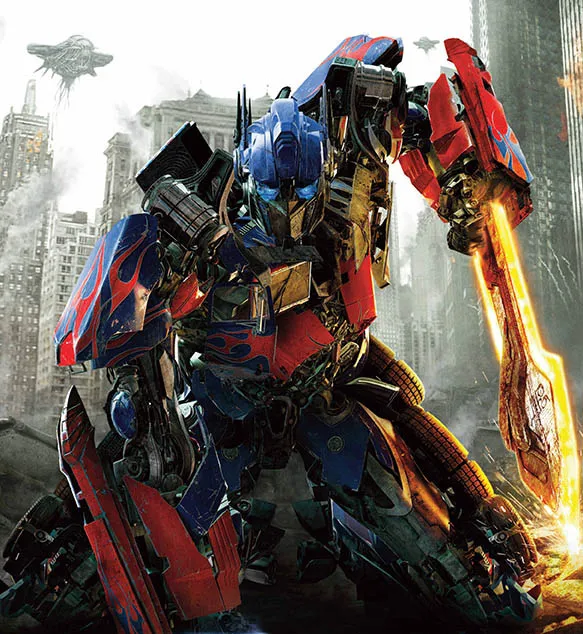

In [4]:
import torch
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

cuda: True
gpu: Tesla T4


## №1

In [6]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 192
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_label_maps(series):
    labels = sorted(series.astype(str).unique().tolist())
    label2id = {l:i for i,l in enumerate(labels)}
    id2label = {i:l for l,i in label2id.items()}
    return label2id, id2label

q2id, id2q = make_label_maps(train_df["queue"])
p2id, id2p = make_label_maps(train_df["priority"])
t2id, id2t = make_label_maps(train_df["type"])

NUM_Q, NUM_P, NUM_T = len(q2id), len(p2id), len(t2id)
print("num labels:", NUM_Q, NUM_P, NUM_T, "total:", NUM_Q + NUM_P + NUM_T)

def to_hf(df):
    tmp = df[["text", "queue", "priority", "type"]].copy()
    tmp["labels"] = list(zip(
        tmp["queue"].astype(str).map(q2id),
        tmp["priority"].astype(str).map(p2id),
        tmp["type"].astype(str).map(t2id),
    ))
    return Dataset.from_pandas(tmp[["text", "labels"]], preserve_index=False)

hf_train = to_hf(train_df)
hf_val   = to_hf(val_df)
hf_test  = to_hf(test_df)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

hf_train = hf_train.map(tok, batched=True, remove_columns=["text"])
hf_val   = hf_val.map(tok, batched=True, remove_columns=["text"])
hf_test  = hf_test.map(tok, batched=True, remove_columns=["text"])

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

num labels: 52 5 5 total: 62


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [8]:
class MultiTaskCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        labels = [f["labels"] for f in features]
        for f in features:
            f.pop("labels", None)

        batch = self.tokenizer.pad(features, return_tensors="pt")
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

collator = MultiTaskCollator(tokenizer)

class XLMRMultiTask(nn.Module):
    def __init__(self, model_name, num_q, num_p, num_t, wq=1.0, wp=0.7, wt=0.7, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_q = nn.Linear(h, num_q)
        self.head_p = nn.Linear(h, num_p)
        self.head_t = nn.Linear(h, num_t)
        self.wq, self.wp, self.wt = wq, wp, wt
        self.num_q, self.num_p, self.num_t = num_q, num_p, num_t

    def mean_pool(self, last_hidden, attn_mask):
        mask = attn_mask.unsqueeze(-1).float()
        summed = (last_hidden * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-6)
        return summed / denom

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        x = self.mean_pool(out.last_hidden_state, attention_mask)
        x = self.drop(x)

        logits_q = self.head_q(x)
        logits_p = self.head_p(x)
        logits_t = self.head_t(x)

        # один logits-тензор (для совместимости с Trainer)
        logits = torch.cat([logits_q, logits_p, logits_t], dim=1)

        loss = None
        if labels is not None:
            yq = labels[:, 0]
            yp = labels[:, 1]
            yt = labels[:, 2]
            loss_q = F.cross_entropy(logits_q, yq)
            loss_p = F.cross_entropy(logits_p, yp)
            loss_t = F.cross_entropy(logits_t, yt)
            loss = self.wq*loss_q + self.wp*loss_p + self.wt*loss_t

        return {"loss": loss, "logits": logits}

device = "cuda" if torch.cuda.is_available() else "cpu"
model = XLMRMultiTask(MODEL_NAME, NUM_Q, NUM_P, NUM_T).to(device)
print("device:", device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda


In [10]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids

    q_logits = logits[:, :NUM_Q]
    p_logits = logits[:, NUM_Q:NUM_Q+NUM_P]
    t_logits = logits[:, NUM_Q+NUM_P:]

    yq, yp, yt = labels[:, 0], labels[:, 1], labels[:, 2]

    pq = np.argmax(q_logits, axis=1)
    pp = np.argmax(p_logits, axis=1)
    pt = np.argmax(t_logits, axis=1)

    q_acc = accuracy_score(yq, pq)
    q_mf1 = f1_score(yq, pq, average="macro")
    p_acc = accuracy_score(yp, pp)
    t_acc = accuracy_score(yt, pt)

    score = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc
    return {
        "queue_acc": q_acc,
        "queue_macro_f1": q_mf1,
        "priority_acc": p_acc,
        "type_acc": t_acc,
        "final_score": score,
    }

ta_sig = inspect.signature(TrainingArguments.__init__).parameters
args_kwargs = dict(
    output_dir="out_transformer_multitask",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    num_train_epochs=1,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="final_score",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,
)

if "fp16" in ta_sig:
    args_kwargs["fp16"] = (device == "cuda")
if "warmup_ratio" in ta_sig:
    args_kwargs["warmup_ratio"] = 0.06
if "evaluation_strategy" in ta_sig:
    args_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in ta_sig:
    args_kwargs["eval_strategy"] = "epoch"

# фильтр на случай несовместимостей версии transformers
args_kwargs = {k: v for k, v in args_kwargs.items() if k in ta_sig}
args = TrainingArguments(**args_kwargs)

tr_sig = inspect.signature(Trainer.__init__).parameters
trainer_kwargs = dict(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)
if "tokenizer" in tr_sig:
    trainer_kwargs["tokenizer"] = tokenizer
elif "processing_class" in tr_sig:
    trainer_kwargs["processing_class"] = tokenizer

trainer = Trainer(**trainer_kwargs)

trainer.train()
test_out = trainer.predict(hf_test)
print("TEST METRICS:", test_out.metrics)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Queue Acc,Queue Macro F1,Priority Acc,Type Acc,Final Score
1,2.207078,2.173050,0.526554,0.751950,0.566386,0.854113,0.739440


TEST METRICS: {'test_loss': 2.1897263526916504, 'test_queue_acc': 0.5250121418164158, 'test_queue_macro_f1': 0.7486379000124526, 'test_priority_acc': 0.5520479197021207, 'test_type_acc': 0.8429658410231504, 'test_final_score': 0.7332985941175075, 'test_runtime': 15.8783, 'test_samples_per_second': 389.021, 'test_steps_per_second': 24.373}


## №2

In [11]:
def make_text_trf(df):
    subj = df["subject"].fillna("").astype(str).str.strip()
    body = df["body"].fillna("").astype(str).str.strip()

    return ("[SUBJECT] " + subj + " [SUBJECT] " + subj + " [BODY] " + body)

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df["text_trf"] = make_text_trf(train_df)
val_df["text_trf"]   = make_text_trf(val_df)
test_df["text_trf"]  = make_text_trf(test_df)

In [13]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_label_maps(series):
    labels = sorted(series.astype(str).unique().tolist())
    label2id = {l:i for i,l in enumerate(labels)}
    id2label = {i:l for l,i in label2id.items()}
    return label2id, id2label

q2id, id2q = make_label_maps(train_df["queue"])
p2id, id2p = make_label_maps(train_df["priority"])
t2id, id2t = make_label_maps(train_df["type"])

NUM_Q, NUM_P, NUM_T = len(q2id), len(p2id), len(t2id)
print("num labels:", NUM_Q, NUM_P, NUM_T)

def to_hf(df):
    tmp = df[["text_trf","queue","priority","type"]].copy()
    tmp["labels"] = list(zip(
        tmp["queue"].astype(str).map(q2id),
        tmp["priority"].astype(str).map(p2id),
        tmp["type"].astype(str).map(t2id),
    ))
    return Dataset.from_pandas(tmp[["text_trf","labels"]], preserve_index=False)

hf_train = to_hf(train_df)
hf_val   = to_hf(val_df)
hf_test  = to_hf(test_df)

def tok(batch):
    return tokenizer(batch["text_trf"], truncation=True, max_length=MAX_LEN)

hf_train = hf_train.map(tok, batched=True, remove_columns=["text_trf"])
hf_val   = hf_val.map(tok, batched=True, remove_columns=["text_trf"])
hf_test  = hf_test.map(tok, batched=True, remove_columns=["text_trf"])

num labels: 52 5 5


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [14]:
class MultiTaskCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
    def __call__(self, features):
        labels = [f["labels"] for f in features]
        for f in features:
            f.pop("labels", None)
        batch = self.tokenizer.pad(features, return_tensors="pt")
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

collator = MultiTaskCollator(tokenizer)

freq = Counter(train_df["queue"].astype(str).values)
w = np.zeros(NUM_Q, dtype=np.float32)
for lbl, idx in q2id.items():
    w[idx] = (1.0 / freq[lbl]) ** 0.5
w = w / w.mean()
queue_weight = torch.tensor(w, dtype=torch.float32)

class XLMRMultiTask(nn.Module):
    def __init__(self, model_name, num_q, num_p, num_t, queue_weight=None, wq=1.0, wp=0.7, wt=0.7, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_q = nn.Linear(h, num_q)
        self.head_p = nn.Linear(h, num_p)
        self.head_t = nn.Linear(h, num_t)
        self.wq, self.wp, self.wt = wq, wp, wt
        self.num_q, self.num_p, self.num_t = num_q, num_p, num_t
        self.register_buffer("queue_weight", queue_weight if queue_weight is not None else None)

    def mean_pool(self, last_hidden, attn_mask):
        mask = attn_mask.unsqueeze(-1).float()
        summed = (last_hidden * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-6)
        return summed / denom

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        x = self.mean_pool(out.last_hidden_state, attention_mask)
        x = self.drop(x)

        logits_q = self.head_q(x)
        logits_p = self.head_p(x)
        logits_t = self.head_t(x)
        logits = torch.cat([logits_q, logits_p, logits_t], dim=1)

        loss = None
        if labels is not None:
            yq, yp, yt = labels[:,0], labels[:,1], labels[:,2]
            loss_q = F.cross_entropy(logits_q, yq, weight=self.queue_weight)
            loss_p = F.cross_entropy(logits_p, yp)
            loss_t = F.cross_entropy(logits_t, yt)
            loss = self.wq*loss_q + self.wp*loss_p + self.wt*loss_t

        return {"loss": loss, "logits": logits}

device = "cuda" if torch.cuda.is_available() else "cpu"
model = XLMRMultiTask(MODEL_NAME, NUM_Q, NUM_P, NUM_T, queue_weight=queue_weight).to(device)
print("device:", device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda


In [15]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids

    q_logits = logits[:, :NUM_Q]
    p_logits = logits[:, NUM_Q:NUM_Q+NUM_P]
    t_logits = logits[:, NUM_Q+NUM_P:]

    yq, yp, yt = labels[:,0], labels[:,1], labels[:,2]
    pq = np.argmax(q_logits, axis=1)
    pp = np.argmax(p_logits, axis=1)
    pt = np.argmax(t_logits, axis=1)

    q_acc = accuracy_score(yq, pq)
    q_mf1 = f1_score(yq, pq, average="macro")
    p_acc = accuracy_score(yp, pp)
    t_acc = accuracy_score(yt, pt)

    score = 0.70*q_mf1 + 0.15*p_acc + 0.15*t_acc
    return {"queue_acc": q_acc, "queue_macro_f1": q_mf1, "priority_acc": p_acc, "type_acc": t_acc, "final_score": score}

ta_sig = inspect.signature(TrainingArguments.__init__).parameters

per_device_bs = 8
grad_accum = 2

steps_per_epoch = int(np.ceil(len(hf_train) / per_device_bs / grad_accum))
warmup_steps = int(0.06 * steps_per_epoch * 1)

args_kwargs = dict(
    output_dir="out_transformer_multitask_v2",
    per_device_train_batch_size=per_device_bs,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=grad_accum,
    learning_rate=2e-5,
    num_train_epochs=1,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="final_score",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,
)

if "fp16" in ta_sig:
    args_kwargs["fp16"] = (device == "cuda")

if "warmup_steps" in ta_sig:
    args_kwargs["warmup_steps"] = warmup_steps

if "evaluation_strategy" in ta_sig:
    args_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in ta_sig:
    args_kwargs["eval_strategy"] = "epoch"

args_kwargs = {k:v for k,v in args_kwargs.items() if k in ta_sig}
args = TrainingArguments(**args_kwargs)

tr_sig = inspect.signature(Trainer.__init__).parameters
trainer_kwargs = dict(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)
if "tokenizer" in tr_sig:
    trainer_kwargs["tokenizer"] = tokenizer
elif "processing_class" in tr_sig:
    trainer_kwargs["processing_class"] = tokenizer

trainer = Trainer(**trainer_kwargs)

trainer.train()
test_out = trainer.predict(hf_test)
print("TEST METRICS:", test_out.metrics)

Epoch,Training Loss,Validation Loss,Queue Acc,Queue Macro F1,Priority Acc,Type Acc,Final Score
1,4.345631,2.386024,0.515382,0.764528,0.541127,0.847636,0.743484


TEST METRICS: {'test_loss': 2.3976593017578125, 'test_queue_acc': 0.506232799093411, 'test_queue_macro_f1': 0.7624739393410349, 'test_priority_acc': 0.5300307592682532, 'test_type_acc': 0.8476606767039015, 'test_final_score': 0.7403854729345476, 'test_runtime': 19.207, 'test_samples_per_second': 321.602, 'test_steps_per_second': 20.149}


## №3 - Абсолютный победитель в разряде трансформеров в этом ноутбуке!

In [48]:
def build_label_maps(series: pd.Series):
    labels = sorted(series.astype(str).unique().tolist())
    label2id = {x: i for i, x in enumerate(labels)}
    id2label = {i: x for x, i in label2id.items()}
    return label2id, id2label

queue_label2id, queue_id2label = build_label_maps(df["queue"])
prio_label2id, prio_id2label   = build_label_maps(df["priority"])
type_label2id, type_id2label   = build_label_maps(df["type"])

def encode_labels(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()
    out["labels_queue"] = out["queue"].map(queue_label2id).astype(int)
    out["labels_priority"] = out["priority"].map(prio_label2id).astype(int)
    out["labels_type"] = out["type"].map(type_label2id).astype(int)
    return out

train_df = encode_labels(train_df)
val_df   = encode_labels(val_df)
test_df  = encode_labels(test_df)

num_queue = len(queue_label2id)
num_prio  = len(prio_label2id)
num_type  = len(type_label2id)

print(num_queue, num_prio, num_type)

52 5 5


In [49]:
def make_class_weights(y: np.ndarray, num_classes: int):
    classes = np.arange(num_classes)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )
    return torch.tensor(weights, dtype=torch.float)

queue_weights = make_class_weights(train_df["labels_queue"].values, num_queue)
prio_weights  = make_class_weights(train_df["labels_priority"].values, num_prio)
type_weights  = make_class_weights(train_df["labels_type"].values, num_type)

In [50]:
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(
    train_df[["text", "labels_queue", "labels_priority", "labels_type"]],
    preserve_index=False
)
val_ds = Dataset.from_pandas(
    val_df[["text", "labels_queue", "labels_priority", "labels_type"]],
    preserve_index=False
)
test_ds = Dataset.from_pandas(
    test_df[["text", "labels_queue", "labels_priority", "labels_type"]],
    preserve_index=False
)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

columns_to_keep = [
    "input_ids", "attention_mask",
    "labels_queue", "labels_priority", "labels_type"
]

train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in columns_to_keep])
val_ds   = val_ds.remove_columns([c for c in val_ds.column_names if c not in columns_to_keep])
test_ds  = test_ds.remove_columns([c for c in test_ds.column_names if c not in columns_to_keep])

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

In [51]:
@dataclass
class MultiTaskCollator:
    tokenizer: Any
    pad_to_multiple_of: Optional[int] = 8

    def __call__(self, features):
        labels_queue = torch.tensor([f["labels_queue"] for f in features], dtype=torch.long)
        labels_priority = torch.tensor([f["labels_priority"] for f in features], dtype=torch.long)
        labels_type = torch.tensor([f["labels_type"] for f in features], dtype=torch.long)

        batch_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"],
            }
            for f in features
        ]

        batch = DataCollatorWithPadding(
            tokenizer=self.tokenizer,
            pad_to_multiple_of=self.pad_to_multiple_of
        )(batch_features)

        batch["labels_queue"] = labels_queue
        batch["labels_priority"] = labels_priority
        batch["labels_type"] = labels_type
        return batch

multi_collator = MultiTaskCollator(tokenizer)

In [52]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        masked = last_hidden_state * mask
        summed = masked.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

class MultiTaskMBERT(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_queue: int,
        num_prio: int,
        num_type: int,
        queue_weights=None,
        prio_weights=None,
        type_weights=None,
        queue_loss_weight=0.80,
        prio_loss_weight=0.10,
        type_loss_weight=0.10,
        dropout=0.2,
        label_smoothing=0.03,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size

        self.pool = MeanPooling()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_size)

        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.prio_head = nn.Linear(hidden_size, num_prio)
        self.type_head = nn.Linear(hidden_size, num_type)

        self.queue_weights = queue_weights
        self.prio_weights = prio_weights
        self.type_weights = type_weights

        self.queue_loss_weight = queue_loss_weight
        self.prio_loss_weight = prio_loss_weight
        self.type_loss_weight = type_loss_weight
        self.label_smoothing = label_smoothing

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels_queue=None,
        labels_priority=None,
        labels_type=None,
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        pooled = self.pool(outputs.last_hidden_state, attention_mask)
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)

        logits_queue = self.queue_head(pooled)
        logits_priority = self.prio_head(pooled)
        logits_type = self.type_head(pooled)

        loss = None
        if labels_queue is not None:
            device = logits_queue.device

            queue_weights = self.queue_weights.to(device) if self.queue_weights is not None else None
            prio_weights  = self.prio_weights.to(device) if self.prio_weights is not None else None
            type_weights  = self.type_weights.to(device) if self.type_weights is not None else None

            loss_queue = F.cross_entropy(
                logits_queue, labels_queue,
                weight=queue_weights,
                label_smoothing=self.label_smoothing,
            )
            loss_priority = F.cross_entropy(
                logits_priority, labels_priority,
                weight=prio_weights,
                label_smoothing=self.label_smoothing,
            )
            loss_type = F.cross_entropy(
                logits_type, labels_type,
                weight=type_weights,
                label_smoothing=self.label_smoothing,
            )

            loss = (
                self.queue_loss_weight * loss_queue +
                self.prio_loss_weight * loss_priority +
                self.type_loss_weight * loss_type
            )

        return {
            "loss": loss,
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type,
        }

In [53]:
def compute_metrics(eval_pred):
    preds, labels = eval_pred

    logits_queue, logits_priority, logits_type = preds
    labels_queue, labels_priority, labels_type = labels

    pred_queue = np.argmax(logits_queue, axis=1)
    pred_prio  = np.argmax(logits_priority, axis=1)
    pred_type  = np.argmax(logits_type, axis=1)

    queue_acc = accuracy_score(labels_queue, pred_queue)
    queue_macro_f1 = f1_score(labels_queue, pred_queue, average="macro")
    priority_acc = accuracy_score(labels_priority, pred_prio)
    type_acc = accuracy_score(labels_type, pred_type)

    final_score = 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc

    return {
        "queue_acc": queue_acc,
        "queue_macro_f1": queue_macro_f1,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score,
    }

In [57]:
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            labels_queue=inputs["labels_queue"],
            labels_priority=inputs["labels_priority"],
            labels_type=inputs["labels_type"],
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        has_labels = all(k in inputs for k in ["labels_queue", "labels_priority", "labels_type"])

        with torch.no_grad():
            outputs = model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                labels_queue=inputs["labels_queue"] if has_labels else None,
                labels_priority=inputs["labels_priority"] if has_labels else None,
                labels_type=inputs["labels_type"] if has_labels else None,
            )

        loss = outputs["loss"].detach() if has_labels and outputs["loss"] is not None else None

        # ВАЖНО: возвращаем torch.Tensor, не numpy
        logits = (
            outputs["logits_queue"].detach(),
            outputs["logits_priority"].detach(),
            outputs["logits_type"].detach(),
        )

        labels = None
        if has_labels:
            labels = (
                inputs["labels_queue"].detach(),
                inputs["labels_priority"].detach(),
                inputs["labels_type"].detach(),
            )

        return (loss, logits, labels)

In [58]:
model = MultiTaskMBERT(
    model_name=MODEL_NAME,
    num_queue=num_queue,
    num_prio=num_prio,
    num_type=num_type,
    queue_weights=queue_weights,
    prio_weights=prio_weights,
    type_weights=type_weights,
    queue_loss_weight=0.80,
    prio_loss_weight=0.10,
    type_loss_weight=0.10,
    dropout=0.2,
    label_smoothing=0.03,
)

training_args = TrainingArguments(
    output_dir="./mbert_multitask",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.05,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,

    fp16=torch.cuda.is_available(),

    load_best_model_at_end=True,
    metric_for_best_model="final_score",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=multi_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Queue Acc,Queue Macro F1,Priority Acc,Type Acc,Final Score
1,1.359645,2.905305,0.396535,0.763091,0.443491,0.783355,0.718191
2,1.203918,2.767894,0.479113,0.844189,0.481380,0.800194,0.783168
3,0.950036,2.693103,0.493038,0.852385,0.507610,0.835978,0.798208


TrainOutput(global_step=9267, training_loss=1.380691421293088, metrics={'train_runtime': 1634.5739, 'train_samples_per_second': 90.688, 'train_steps_per_second': 5.669, 'total_flos': 0.0, 'train_loss': 1.380691421293088, 'epoch': 3.0})

In [59]:
val_metrics = trainer.evaluate(val_ds)
print("VAL:", val_metrics)

test_metrics = trainer.evaluate(test_ds)
print("TEST:", test_metrics)

VAL: {'eval_loss': 2.693103313446045, 'eval_queue_acc': 0.49303756476683935, 'eval_queue_macro_f1': 0.8523849993471041, 'eval_priority_acc': 0.507610103626943, 'eval_type_acc': 0.8359779792746114, 'eval_final_score': 0.7982077119782061, 'eval_runtime': 13.1705, 'eval_samples_per_second': 468.928, 'eval_steps_per_second': 14.654, 'epoch': 3.0}
TEST: {'eval_loss': 2.7321438789367676, 'eval_queue_acc': 0.49878581835842645, 'eval_queue_macro_f1': 0.8522523065882285, 'eval_priority_acc': 0.48777723814149265, 'eval_type_acc': 0.8274243160110086, 'eval_final_score': 0.7938568477346352, 'eval_runtime': 13.2581, 'eval_samples_per_second': 465.905, 'eval_steps_per_second': 14.633, 'epoch': 3.0}


# Вывод

В ходе работы был проведён EDA датасета обращений в поддержку, построен baseline на основе TF-IDF и линейной модели, а также реализован transformer fine-tuning в multitask-постановке для предсказания queue, priority и type

Лучший результат показал TF-IDF: он превзошёл transformer по итоговому final_score. Это говорит о том, что для данной задачи линейная модель на разреженных текстовых признаках является очень сильным и труднопробиваемым baseline!

Multitask transformer также показал рабочий и стабильный результат, однако уступил лучшему TF-IDF. Основная сложность для transformer-модели была связана с дисбалансом классов, особенно в задаче queue, а также с более слабым качеством на priority.

Таким образом, в рамках данного датасета наиболее эффективным решением оказался TF-IDF baseline, а transformer fine-tuning выступил как полезный дополнительный эксперимент и подтвердил, что нейросетевой подход не всегда автоматически превосходит классические методы